## **Importing Packages and Modules**

In [6]:
import re
import sys
import os
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from dotenv import load_dotenv
from pathlib import Path

## **Appending Paths**

In [7]:
# Merging the path

sys.path.append(os.path.abspath('../../'))
from src.cleaning_utils import parse_mixed_dates , clean_yes_no_column

## **Loading Env**

In [8]:
# 1. Load the .env file
load_dotenv()

True

## **Reading Data**

In [9]:
folder_path = os.getenv("RAW_DATA_FOLDER")
dir_files=os.listdir(folder_path)

# Creating File Paths
files=[]
for file in dir_files:
    files.append(folder_path+"/"+file)

*Extracting the path from the location*

In [10]:
# Sorting Files for Ensuring Idempotency
files=sorted(files)

# Reading Data
billings=pd.read_csv(files[0])
cc_calls=pd.read_csv(files[1])
emails=pd.read_csv(files[2])
renewal_calls=pd.read_csv(files[3])

C:\Users\JacksonDivakarRajasi\AppData\Local\Temp\ipykernel_15668\2319032097.py:5: DtypeWarning: Columns (15,16,19,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  billings=pd.read_csv(files[0])
C:\Users\JacksonDivakarRajasi\AppData\Local\Temp\ipykernel_15668\2319032097.py:7: DtypeWarning: Columns (16,19) have mixed types. Specify dtype option on import or set low_memory=False.
  emails=pd.read_csv(files[2])
C:\Users\JacksonDivakarRajasi\AppData\Local\Temp\ipykernel_15668\2319032097.py:8: DtypeWarning: Columns (4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  renewal_calls=pd.read_csv(files[3])


## **EDA**


#### **Feature Documentation**

| Column Name | Data Type | Missing % | Description |
|-------------|-----------|-----------|-------------|
| `Call_ID` | float64 | 0.00% | Unique identifier for each call record. Used for counting calls, not as a predictive feature. |
| `Call_Direction` | object | 0.00% | Direction of the call: `Inbound` or `Outbound`. |
| `Co_Ref` | object | 3.96% | Customer reference (unique identifier). Primary key for customer‑level aggregation. |
| `Call_Date` | object | 0.00% | Date of the call. Used to derive recency features. |
| `Churn_Category` | object | 95.76% | Categorisation of churn reason. Mostly missing – filled with `Unclassified`. |
| `Complaint_Category` | object | 89.81% | Type of complaint logged. Mostly missing – filled with `Unclassified`. |
| `Customer_Reaction_Category` | object | 87.62% | Customer’s emotional/behavioural reaction (e.g., angry, satisfied). Filled with `Not Mentioned`. |
| `Agent_Renewal_Pitch_Category` | object | 71.19% | Type of renewal pitch made by the agent. Filled with `Not Mentioned`. |
| `Customer_Renewal_Response_Category` | object | 70.88% | Customer’s response to renewal discussion. Filled with `Not Mentioned`. |
| `Agent_Response_Category` | object | 71.06% | How the agent handled the customer’s queries/objections. Filled with `Not Mentioned`. |
| `Membership_Renewal_Decision` | object | 53.59% | Customer’s verbal renewal intent (Yes/No). Cleaned to `Yes`/`No`/`N/A`. |
| `Serious_Complaint` | object | 54.79% | Flag for serious complaint. Cleaned to `Yes`/`No`/`N/A`. |
| `Other_Complaint` | object | 54.79% | Flag for minor/general complaint. Cleaned to `Yes`/`No`/`N/A`. |
| `Discussion_on_Price_Increase` | object | 52.81% | Whether a price increase was discussed. Cleaned to `Yes`/`No`/`N/A`. |
| `Renewal_Impact_Due_to_Price_Increase` | object | 52.82% | Whether price increase impacted renewal decision. Cleaned to `Yes`/`No`/`N/A`. |
| `Discount_or_Waiver_Requested` | object | 52.82% | Whether customer requested a discount/waiver. Cleaned to `Yes`/`No`/`N/A`. |
| `Call_Reschedule_Request` | object | 52.51% | Whether call was rescheduled. Cleaned to `Yes`/`No`/`N/A`. |
| `Agent_Flagged_Membership_Status_Alert` | object | 52.51% | Whether agent flagged a membership alert. Cleaned to `Yes`/`No`/`N/A`. |
| `Agent_Renewal_Initiation` | object | 52.51% | Whether agent initiated renewal discussion. Cleaned to `Yes`/`No`/`N/A`. |
| `Explicit_Competitor_Mention` | object | 52.45% | Whether competitor was explicitly mentioned. Cleaned to `Yes`/`No`/`N/A`. |
| `Unnamed: 20` | – | 100.00% | Empty column – dropped during cleaning. |
| `Explicit_Switching_Intent` | object | 52.45% | Whether customer explicitly stated intent to switch to competitor. Cleaned to `Yes`/`No`/`N/A`. |
| `Mentioned_Competitors` | object | 52.45% | Names of competitors mentioned. Mostly missing; not used in final model. |
| `Price_Switching_Mentioned` | object | 52.47% | Whether price was mentioned as reason for switching. Cleaned to `Yes`/`No`/`N/A`. |
| `Competitor_Value_Comparison` | object | 52.47% | Customer’s comparison of competitor value (Better/Similar/Not Discussed). Cleaned. |
| `Competitor_Benefits_Mentioned` | object | 53.59% | Benefits of competitors mentioned (e.g., price, service). One‑hot encoded into 5 categories. |
| `Topic_Introduced_By` | object | 52.44% | Who introduced the topic (Agent/Customer). Filled with `N/A`. |
| `Percentage_Price_Increase_Mentioned` | object | 52.44% | Whether a percentage price increase was mentioned. Cleaned to `Yes`/`No`/`N/A`. |
| `Monetary_Price_Increase_Mentioned` | object | 52.44% | Whether a monetary price increase was mentioned. Cleaned to `Yes`/`No`/`N/A`. |
| `Price_Range_Mentioned` | object | 52.44% | Price range mentioned (e.g., “£500 to £600”). Used to derive `mid_price_log`. |
| `Customer_Asked_For_Justification` | object | 52.44% | Whether customer asked for justification of price/policy. Cleaned to `Yes`/`No`/`N/A`. |
| `Customer_Response` | object | 52.44% | Customer’s overall response sentiment (Positive/Neutral/Negative). Filled with `N/A`. |
| `Desire_To_Cancel` | object | 52.44% | Raw text of customer’s cancellation desire. Cleaned into `desire_to_cancel_clean`. |
| `Discount_Offered` | object | 52.44% | Whether agent offered a discount. Cleaned to `Yes`/`No`/`N/A`. |
| `Justification_Category` | object | 92.99% | Category of justification given. Mostly missing – filled with `N/A`. |
| `Reason_For_Renewal_Category` | object | 91.35% | Reason customer gave for renewing. Mostly missing – filled with `N/A`. |
| `Agent_Response_To_Cancel_Category` | object | 97.36% | How agent responded to cancellation intent. Mostly missing – filled with `N/A`. |
| `Argument_That_Convinced_Customer_to_Stay_Category` | object | 99.03% | Argument that retained the customer. Almost all missing – filled with `N/A`. |
| `Analysed_Call` | float64 | 52.42% | Flag indicating if call was analysed (1/0). Not used in final model. |
| `Call_Number` | int64 | 0.00% | Sequence number of the call for the customer. Not used in final model. |
| `Call_Year` | int64 | 0.00% | Year of the call. Not used (derived from `Call_Date`). |

---

*Unnamed: 20 column is a blank column*

## **Data Cleaning**

### **Unnamed: 20**

In [11]:
renewal_calls.drop("Unnamed: 20",axis=1,inplace=True)

*Dropping the empty column*

### **Co refs**

In [12]:
renewal_calls.dropna(subset=["Co_Ref"],inplace=True)

*Co ref is a customer key for joining the table . Null Value in this high cardinal feature might misinterpret the data so we are dropping here.*

### **Cleaning Call Direction**

In [13]:
renewal_calls["Call_Direction"]=renewal_calls["Call_Direction"].replace({"OUT_BOUND":"Outbound","IN_BOUND":"Inbound"})
renewal_calls=renewal_calls[renewal_calls["Call_Direction"].isin(["Inbound", "Outbound"])]

*Standardizing the column values*

## **Handling Null Values**

### **Filling Missing Categories**

In [14]:
def fill_missing_categories(df, columns, fill_value="Not Mentioned"):
    """
    Fills null values in specified columns of a DataFrame.

    Args:
        df (pd.DataFrame): The target DataFrame.
        columns (list): A list of column names to update.
        fill_value (str): The string to replace NaN with.
    """
    for col in columns:
        if col in df.columns:
            df[col] = df[col].fillna(fill_value)
        else:
            print(f"Warning: Column '{col}' not found in DataFrame.")
    return df

# Handling the "Unclassified" group
unclassified_cols = ["Churn_Category", "Complaint_Category"]
renewal_calls = fill_missing_categories(renewal_calls, unclassified_cols, "Unclassified")

# Handling the "Not Mentioned" group
not_mentioned_cols = [
    "Customer_Reaction_Category",
    "Agent_Renewal_Pitch_Category",
    "Customer_Renewal_Response_Category",
    "Agent_Response_Category"
]
renewal_calls = fill_missing_categories(renewal_calls, not_mentioned_cols, "Not Mentioned")

### **Cleaning Binary Columns (Yes/No) Columns**

In [15]:
def clean_multiple_yes_no_columns(df, column_names=None, index_range=None):
    """
    Cleans multiple Yes/No columns in a DataFrame using the clean_yes_no_column function.

    Args:
        df (pd.DataFrame): The target DataFrame.
        column_names (list): List of specific column names to clean.
        index_range (tuple): A tuple (start, end) for a range of column indices.
    """
    # 1. Clean columns provided by name
    if column_names:
        for col in column_names:
            if col in df.columns:
                df = clean_yes_no_column(df, col)
            else:
                print(f"Warning: Column '{col}' not found.")

    # 2. Clean columns provided by index range
    if index_range:
        start, end = index_range
        cols_to_clean = df.columns[start:end]
        for col in cols_to_clean:
            df = clean_yes_no_column(df, col)

    return df


# Columns to Clean
target_cols = [
    "Membership_Renewal_Decision",
    "Renewal_Impact_Due_to_Price_Increase",
    "Serious_Complaint",
    "Other_Complaint",
    "Discussion_on_Price_Increase",
    "Discount_or_Waiver_Requested",
    "Call_Reschedule_Request"
]

renewal_calls = clean_multiple_yes_no_columns(
    renewal_calls,
    column_names=target_cols,
    index_range=(17, 23)
)

### **Filling Other Suitable Columns with N/A**

In [16]:
not_available_columns=['Justification_Category', 'Reason_For_Renewal_Category', 'Agent_Response_To_Cancel_Category', 'Argument_That_Convinced_Customer_to_Stay_Category']
for col in not_available_columns:
  renewal_calls=renewal_calls.fillna({col:"N/A" for col in not_available_columns})

### **Competitor Value Comparison Column**

**It is structurally corrupted.**
It contains:
1) Instructions mixed with answers
2) Multiple answers inside one string
3) Free text + labels combined
4) Invalid formats (“N/A”, numbers, sentences)
5) Target labels hidden inside noise (“Similar Value”, “Better Value”)

In [17]:
def extract_competitor_info(x):
    if pd.isna(x):
        return "Unknown"

    x = str(x).lower()

    # priority order
    if "better value" in x:
        return "Better Value"
    if "similar value" in x:
        return "Similar Value"
    if "not discussed" in x:
        return "Not Discussed"
    if re.search(r'\bno\b', x):
        return "No"
    if any(char.isdigit() for char in x):
        return "Price Mentioned"

    return "Unknown"

renewal_calls["Competitor_Value_Comparison"]=renewal_calls["Competitor_Value_Comparison"].apply(extract_competitor_info)

### **Competitor Benefits Mentioned Column**

*This column is about is a **decomposition of customer reasoning.***

In [18]:
# Defining Standard Categories
CATEGORIES = {
    "price": ["cheaper", "lower price", "cost", "discount", "pricing"],
    "service": ["better service", "support", "assistance"],
    "offering": ["offering", "features", "comprehensive"],
    "process": ["easy", "faster", "time-saving"],
    "recognition": ["accreditation", "recognition"],
}

# Extract Benefits
def extract_benefits(x):
    if pd.isna(x):
        return []

    x = str(x).lower()
    found = []

    for category, keywords in CATEGORIES.items():
        if any(k in x for k in keywords):
            found.append(category)

    return list(set(found))  # remove duplicates

renewal_calls["Competitor_Benefits_Mentioned"] = renewal_calls["Competitor_Benefits_Mentioned"].apply(extract_benefits)


# Cleaning with the multi label approach
# Step 1: Ensuring list format (safety)
renewal_calls["Competitor_Benefits_Mentioned"] = renewal_calls["Competitor_Benefits_Mentioned"].apply(
    lambda x: x if isinstance(x, list) else []
)

# Step 2: Applying MultiLabelBinarizer
mlb = MultiLabelBinarizer()
encoded = mlb.fit_transform(renewal_calls["Competitor_Benefits_Mentioned"])

# Step 3: Creating DataFrame
df_multi = pd.DataFrame(
    encoded,
    columns=mlb.classes_,
    index=renewal_calls.index
)
# Step 4: Merging with original data
renewal_calls = pd.concat([renewal_calls, df_multi], axis=1)

# Step 5: Dropping original list column (important)
renewal_calls = renewal_calls.drop(columns=["Competitor_Benefits_Mentioned"])

### **Analyzing and Filling N/A**

In [19]:
def analyze_and_fill_na(df, columns, fill_value="N/A"):
    """
    Prints percentage distribution including NaNs,
    then fills NaNs with a specified value.
    """
    for col in columns:
        if col in df.columns:
            print(f"--- Distribution for: {col} ---")
            # Calculating and print the percentage distribution
            proportions = df[col].value_counts(dropna=False, normalize=True) * 100
            print(proportions)
            print("\n")

            # Filling the missing values
            df[col] = df[col].fillna(fill_value)
        else:
            print(f"Warning: Column '{col}' not found.")
    return df


# Defining the list of columns
columns_to_process = [
    "Topic_Introduced_By",
    "Percentage_Price_Increase_Mentioned",
    "Monetary_Price_Increase_Mentioned",
    "Customer_Asked_For_Justification",
    "Customer_Response",
    "Discount_Offered"
]

# Running it all in one go
renewal_calls = analyze_and_fill_na(renewal_calls, columns_to_process)

--- Distribution for: Topic_Introduced_By ---
Topic_Introduced_By
NaN              52.600908
Not Discussed    35.257802
Agent             9.156624
Customer          2.984666
Name: proportion, dtype: float64


--- Distribution for: Percentage_Price_Increase_Mentioned ---
Percentage_Price_Increase_Mentioned
NaN              52.600908
No               46.716420
Yes               0.366734
Not Discussed     0.315938
Name: proportion, dtype: float64


--- Distribution for: Monetary_Price_Increase_Mentioned ---
Monetary_Price_Increase_Mentioned
NaN              52.600908
No               45.471088
Yes               1.612066
Not Discussed     0.315938
Name: proportion, dtype: float64


--- Distribution for: Customer_Asked_For_Justification ---
Customer_Asked_For_Justification
NaN              52.600908
No               43.947217
Yes               3.135379
Not Discussed     0.316496
Name: proportion, dtype: float64


--- Distribution for: Customer_Response ---
Customer_Response
NaN             

### **Price Range Mentioned Column**

In [20]:
def parse_price_numeric(x):
    if pd.isna(x):
        return (np.nan, np.nan)

    x_str = str(x).lower()

    nums = re.findall(r'\d+\.?\d*', x_str)

    if len(nums) >= 2:
        n1, n2 = float(nums[0]), float(nums[1])
        return min(n1, n2), max(n1, n2)

    return (np.nan, np.nan)

renewal_calls[['min_price_mentioned', 'max_price_mentioned']] = renewal_calls["Price_Range_Mentioned"].apply(
    lambda x: pd.Series(parse_price_numeric(x))
)

### **Desire_to_Cancel Column**

In [21]:
# Defining Standard Categories
CATEGORIES = [
    "Cancel",
    "Renew",
    "Undecided",
    "Not Discussed",
    "Mixed"
]

# Mapping Desires
def map_desire(x):
    if pd.isna(x):
        return "Not Discussed"

    x = str(x).lower()

    # highest priority: explicit cancel
    if "cancel" in x:
        if "renew" in x:
            return "Mixed"
        return "Cancel"

    # renew cases
    if "renew" in x:
        return "Renew"

    # undecided / unclear
    if any(word in x for word in ["unclear", "undecided", "consider", "not decided"]):
        return "Undecided"

    # not discussed
    if "not discussed" in x or "not applicable" in x:
        return "Not Discussed"

    return "Undecided"

renewal_calls['desire_to_cancel_clean'] = renewal_calls['Desire_To_Cancel'].apply(map_desire)

## **Feature Engineering**

In [22]:
renewal_calls['mid_price'] = (renewal_calls['min_price_mentioned'] + renewal_calls['max_price_mentioned'])/2
renewal_calls['mid_price'].describe()

count      4169.000000
mean       1033.891242
std        5507.770126
min           0.500000
25%         399.000000
50%         589.000000
75%         774.000000
max      143880.000000
Name: mid_price, dtype: float64

### **Plotting Distribution**

<Axes: xlabel='mid_price', ylabel='Count'>

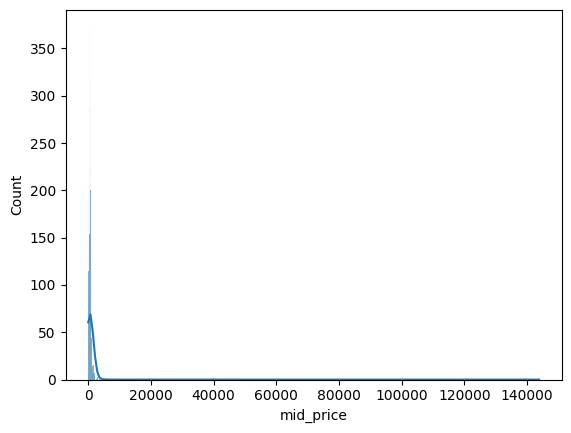

In [23]:
sns.histplot(renewal_calls['mid_price'], kde=True)

**This distribution has heavy skew + extreme outliers:**

1)Median: 589

2)75%: 774

3)Max: 143880 (irrelevant outlier)

Uniform bins will fail.

## **Feature Engineering New Transformed Column**

In [24]:
renewal_calls['mid_price_capped'] = renewal_calls['mid_price'].clip(upper=5000)
renewal_calls['mid_price_log'] = np.log1p(renewal_calls['mid_price_capped'])

### **Plotting Distribution**

<Axes: xlabel='mid_price_log', ylabel='Count'>

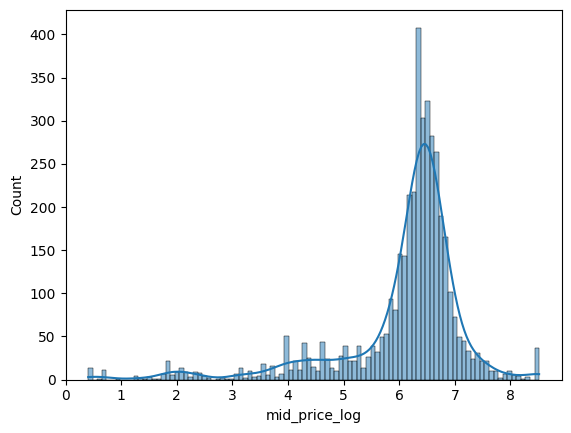

In [25]:
sns.histplot(renewal_calls['mid_price_log'], kde=True)

In [26]:
bins = [
    0,
    393,   # Q1
    589,   # median
    774,   # Q3
    1000,
    1500,
    5000
]

labels = [
    "Low",
    "Lower-Mid",
    "Mid",
    "Upper-Mid",
    "High",
    "Very High"
]

renewal_calls['price_bucket'] = pd.cut(
    renewal_calls['mid_price_capped'],
    bins=bins,
    labels=labels
)

renewal_calls['mid_price_log_flag'] = renewal_calls['mid_price_log'].isna().astype(int)

*Prices are kept nan because the discussion results are customer intent results*

## **Clearning Columns For Aggregation**

In [27]:
cleaned_renewal_calls=renewal_calls.drop(["mid_price","mid_price_capped",'min_price_mentioned', 'max_price_mentioned','Analysed_Call','Call_Number','Desire_To_Cancel','Price_Range_Mentioned'],axis=1)

Dropping Root uncleaned columns


Note : Analysed_Call, Call_Number are not required for modelling

## **Duplicate Handling**

In [28]:
cleaned_renewal_calls.duplicated().sum()

np.int64(26067)

In [29]:
print("Total Duplicate Percentage " , round((cleaned_renewal_calls.duplicated().sum()/cleaned_renewal_calls.shape[0])*100,2))

Total Duplicate Percentage  14.55


#### **Inspecting First Calls Alone**

In [30]:
cleaned_renewal_calls[cleaned_renewal_calls.duplicated(keep='first')].sort_values(by="Co_Ref").head()

,Call_ID,Call_Direction,Co_Ref,Call_Date,Churn_Category,Complaint_Category,Customer_Reaction_Category,Agent_Renewal_Pitch_Category,Customer_Renewal_Response_Category,Agent_Response_Category,...,Call_Year,offering,price,process,recognition,service,desire_to_cancel_clean,mid_price_log,price_bucket,mid_price_log_flag
137069,5.120000e+11,Inbound,AA0994,22-07-2024,Unclassified,Unclassified,Not Mentioned,Not Mentioned,Not Mentioned,Not Mentioned,...,2024,0,0,0,0,0,Not Discussed,NaN,NaN,1
145960,5.650000e+11,Outbound,AA1246,14-10-2024,Unclassified,Unclassified,Not Mentioned,Not Mentioned,Not Mentioned,Not Mentioned,...,2024,0,0,0,0,0,Not Discussed,NaN,NaN,1
152526,5.090000e+11,Outbound,AA1392,31-05-2024,Unclassified,Unclassified,Not Mentioned,Not Mentioned,Not Mentioned,Not Mentioned,...,2024,0,0,0,0,0,Not Discussed,NaN,NaN,1
124554,6.790000e+11,Outbound,AA2580,30-07-2025,Unclassified,Unclassified,Not Mentioned,Not Mentioned,Not Mentioned,Not Mentioned,...,2025,0,0,0,0,0,Not Discussed,NaN,NaN,1
120243,6.250000e+11,Outbound,AA2716,24-04-2025,Unclassified,Unclassified,Not Mentioned,Not Mentioned,Not Mentioned,Not Mentioned,...,2025,0,0,0,0,0,Not Discussed,NaN,NaN,1


#### **Inspecting All Calls**

In [31]:
cleaned_renewal_calls[cleaned_renewal_calls.duplicated(keep=False)].sort_values(by="Co_Ref").head()

,Call_ID,Call_Direction,Co_Ref,Call_Date,Churn_Category,Complaint_Category,Customer_Reaction_Category,Agent_Renewal_Pitch_Category,Customer_Renewal_Response_Category,Agent_Response_Category,...,Call_Year,offering,price,process,recognition,service,desire_to_cancel_clean,mid_price_log,price_bucket,mid_price_log_flag
137037,5.120000e+11,Inbound,AA0994,22-07-2024,Unclassified,Unclassified,Not Mentioned,Not Mentioned,Not Mentioned,Not Mentioned,...,2024,0,0,0,0,0,Not Discussed,NaN,NaN,1
137069,5.120000e+11,Inbound,AA0994,22-07-2024,Unclassified,Unclassified,Not Mentioned,Not Mentioned,Not Mentioned,Not Mentioned,...,2024,0,0,0,0,0,Not Discussed,NaN,NaN,1
145959,5.650000e+11,Outbound,AA1246,14-10-2024,Unclassified,Unclassified,Not Mentioned,Not Mentioned,Not Mentioned,Not Mentioned,...,2024,0,0,0,0,0,Not Discussed,NaN,NaN,1
145960,5.650000e+11,Outbound,AA1246,14-10-2024,Unclassified,Unclassified,Not Mentioned,Not Mentioned,Not Mentioned,Not Mentioned,...,2024,0,0,0,0,0,Not Discussed,NaN,NaN,1
152526,5.090000e+11,Outbound,AA1392,31-05-2024,Unclassified,Unclassified,Not Mentioned,Not Mentioned,Not Mentioned,Not Mentioned,...,2024,0,0,0,0,0,Not Discussed,NaN,NaN,1


**Case A: low unique call_number**

→ Same call repeated many times

→ data issue

**Case B: high unique call_number**

→ Different calls collapsed into identical features

→ feature compression effect

#### **Dropping By Unique Call ID**

In [32]:
cleaned_renewal_calls = cleaned_renewal_calls.drop_duplicates()

#### **Duplicated Percent After Dropping**

In [33]:
print("Total Duplicate Percentage " , round((cleaned_renewal_calls.duplicated().sum()/cleaned_renewal_calls.shape[0])*100,2))

Total Duplicate Percentage  0.0


## **Type Casting Features**

In [34]:
cleaned_renewal_calls=parse_mixed_dates(cleaned_renewal_calls,"Call_Date")

#### **Dataframe After Cleaning**

In [35]:
cleaned_renewal_calls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 153082 entries, 0 to 186533
Data columns (total 44 columns):
 #   Column                                             Non-Null Count   Dtype         
---  ------                                             --------------   -----         
 0   Call_ID                                            153082 non-null  float64       
 1   Call_Direction                                     153082 non-null  object        
 2   Co_Ref                                             153082 non-null  object        
 3   Call_Date                                          153082 non-null  datetime64[ns]
 4   Churn_Category                                     153082 non-null  object        
 5   Complaint_Category                                 153082 non-null  object        
 6   Customer_Reaction_Category                         153082 non-null  object        
 7   Agent_Renewal_Pitch_Category                       153082 non-null  object        
 8   Customer_

## **Aggregating the Features**

In [36]:
# STEP 1: Sort the data to ensure chronological accuracy

# Sorting by Customer (Co_Ref) and then Call_Date (oldest to newest)
# This guarantees that using 'last' in our aggregation grabs the most recent call.
cleaned_renewal_calls = cleaned_renewal_calls.sort_values(by=['Co_Ref', 'Call_Date'])


# STEP 2: Define the Aggregation Rules

aggregation_rules = {
    # --- Volume & Recency Metrics ---
    'Call_ID': 'count',                     # Total calls in the 135-day window
    'Call_Date': 'max',                     # Date of the most recent call

    # --- Customer Sentiment & Intent (Grab the final state before 45-day cutoff) ---
    'desire_to_cancel_clean': 'last',
    'Customer_Reaction_Category': 'last',
    'Customer_Asked_For_Justification': 'last',
    'Membership_Renewal_Decision': 'last',
    'Explicit_Switching_Intent': 'last',

    # --- Financial Discussions ---
    'mid_price_log': 'mean',                # Average price discussed (Pandas ignores NaNs automatically)
    'mid_price_log_flag': 'min',            # 0 if price was EVER discussed, 1 if NEVER discussed
    'Discussion_on_Price_Increase': 'last',
    'Discount_Offered': 'last',

    # --- Competitor Benefits (Accumulate mentions across all calls) ---
    'offering': 'sum',
    'price': 'sum',
    'process': 'sum',
    'recognition': 'sum',
    'service': 'sum',

    # --- Complaints & Issues (Most recent state) ---
    'Serious_Complaint': 'last',
    'Other_Complaint': 'last',

    # --- Agent Actions ---
    'Agent_Renewal_Initiation': 'last',
    'Agent_Response_Category': 'last',
    'Discount_or_Waiver_Requested': 'last',


}

# STEP 3: Execute the Aggregation
customer_level_features = cleaned_renewal_calls.groupby(['Co_Ref']).agg(aggregation_rules).reset_index()

# Rename the 'Call_ID' column to be descriptive
customer_level_features.rename(columns={'Call_ID': 'Total_Calls_In_Window'}, inplace=True)

### 1. Columns We Already Replaced or Cleaned
we did some excellent feature engineering to clean up messy text, so we want to use our *new* columns and drop the old ones to avoid redundancy.
* **Excluded:** `Desire_To_Cancel` (Replaced by your `desire_to_cancel_clean`)
* **Excluded:** `Competitor_Benefits_Mentioned` (Replaced by your one-hot encoded `offering`, `price`, `process`, `recognition`, `service`)
* **Excluded:** `Competitor_Value_Comparison` (Extracted this into a cleaner format earlier)
* **Excluded:** `Price_Range_Mentioned`, `min_price_mentioned`, `max_price_mentioned`, `mid_price_capped` (Replaced by `mid_price_log`)

### 2. Columns with Massive Missing Data (N/A)
In the EDA , we have found that several columns were almost entirely missing or "Unclassified". Including these adds noise rather than signal.
* **Excluded:** `Churn_Category` (95% missing/Unclassified)
* **Excluded:** `Complaint_Category` (89% missing)
* **Excluded:** `Justification_Category` (92% missing)
* **Excluded:** `Reason_For_Renewal_Category` (91% missing)
* **Excluded:** `Agent_Response_To_Cancel_Category` (97% missing)

### 3. Pure Identifiers and Admin Columns
These are necessary for tracking and joining, but they have no mathematical value for a machine learning model to learn from.
* **Excluded:** `Call_ID` (We only use this to *count* the number of calls, the ID itself is useless).
* **Excluded:** `Co_Ref` (We group by this, but it isn't a feature).
* **Excluded:**  `Call_Number`, `Analysed_Call`.

---





### **Date Since Last Call Feature**

In [37]:
max_date = customer_level_features['Call_Date'].max()
customer_level_features['days_since_last_call'] = (max_date - customer_level_features['Call_Date']).dt.days

*This feature is for finding the recency impacts the churn rate*

## **Billings Data Deduplication**

#### **Billing Dataset Data Cleaning**

In [38]:
billings_df=parse_mixed_dates(billings,"Prospect_Renewal_Date")

#### **Cleaning Target Feature**

In [39]:
billings_df["Prospect_Outcome"].unique()

array(['Won', 'Open', 'Churned'], dtype=object)

In [40]:
billings_df.loc[billings_df["Prospect_Outcome"] == "Open", "Prospect_Outcome"] = "Won"

#### **Deduplication**

In [41]:
# Check how many duplicate Co_Refs exist in the billings table
duplicate_billings = billings_df.duplicated(subset=['Co_Ref'], keep=False).sum()
print(f"Total rows in billings belonging to a duplicate Co_Ref: {duplicate_billings}")

Total rows in billings belonging to a duplicate Co_Ref: 109890


In [42]:
# Check how many duplicate Co_Refs exist in the billings table
duplicate_billings = billings_df.duplicated(subset=['Co_Ref','Renewal_Year'], keep=False).sum()
print(f"Total rows in billings belonging to a duplicate Co_Ref: {duplicate_billings}")

Total rows in billings belonging to a duplicate Co_Ref: 0


*Renewal Year + Co_Ref is an unique identifier*

In [43]:
# 1. Extract historical patterns from the FULL billings table before dropping duplicates
billing_history_features = billings_df.groupby('Co_Ref').agg(
    # How many times has this customer renewed before? (Tenure)
    Total_Past_Contracts=('Co_Ref', 'count'),

    # Example: If you have a column for historical revenue, you could sum it
    # Total_Lifetime_Value=('Revenue_Column', 'sum')
).reset_index()


# 2. Now deduplicate to get the Target (like we did before)
billings_sorted = billings_df.sort_values(by=['Co_Ref', 'Prospect_Renewal_Date'])
billings_unique = billings_sorted.drop_duplicates(subset=['Co_Ref'], keep='last')


## **Joining Tables For 45 Day Out**

In [44]:
final_testing_data = customer_level_features.merge(
    billing_history_features, # Add the historical billing patterns (Tenure, etc.)
    on='Co_Ref',
    how='inner'
).merge(
    billings_unique[['Co_Ref', 'Prospect_Outcome']], # Add the final 1/0 Target
    on='Co_Ref',
    how='inner'
)

## **Testing Data Export**

In [45]:
final_testing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35839 entries, 0 to 35838
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Co_Ref                            35839 non-null  object        
 1   Total_Calls_In_Window             35839 non-null  int64         
 2   Call_Date                         35839 non-null  datetime64[ns]
 3   desire_to_cancel_clean            35839 non-null  object        
 4   Customer_Reaction_Category        35839 non-null  object        
 5   Customer_Asked_For_Justification  35839 non-null  object        
 6   Membership_Renewal_Decision       35839 non-null  object        
 7   Explicit_Switching_Intent         35839 non-null  object        
 8   mid_price_log                     3517 non-null   float64       
 9   mid_price_log_flag                35839 non-null  int64         
 10  Discussion_on_Price_Increase      35839 non-nu

In [46]:

output_folder_path = os.getenv("CLEAN_DATA_FOLDER")
final_testing_data.to_csv(output_folder_path+"/renewal_clean.csv",index=False)